<a href="https://colab.research.google.com/github/jhonnygf/Regresion/blob/main/regresion_mpg_colab_style.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de `fuel_efficiency_mpg`

Dataset: `https://raw.githubusercontent.com/bigdatadatafan/datasets-clase/main/car_fuel_efficiency.csv`

Features: `engine_displacement`, `horsepower`, `vehicle_weight`, `model_year`
Target: `fuel_efficiency_mpg`


In [14]:
#@title Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)


In [15]:
#@title Cargar dataset y seleccionar columnas
url = 'https://raw.githubusercontent.com/bigdatadatafan/datasets-clase/main/car_fuel_efficiency.csv'
df = pd.read_csv(url)

cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = df[cols].copy()

print('Dimensiones:', df.shape)
df.head()


Dimensiones: (9704, 5)


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


In [16]:
#@title Missing values y mediana de horsepower
na_counts = df.isna().sum()
print('NaN por columna:\n', na_counts)

median_hp = df['horsepower'].median()
print('\nMediana de horsepower:', median_hp)


NaN por columna:
 engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Mediana de horsepower: 149.0


In [17]:
#@title Train/Test split (sin fugas)
X = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']]
y = df['fuel_efficiency_mpg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape


((7763, 4), (1941, 4))

In [18]:
#@title Baseline: LinearRegression (Pipeline con imputación+escala)
linreg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

linreg_pipe.fit(X_train, y_train)
y_pred_lr = linreg_pipe.predict(X_test)

rmse_lr = mean_squared_error(y_test, y_pred_lr)**0.5
r2_lr   = r2_score(y_test, y_pred_lr)

print(f'Baseline LinearRegression -> RMSE: {rmse_lr:.3f} | R²: {r2_lr:.3f}')

Baseline LinearRegression -> RMSE: 0.470 | R²: 0.966


In [19]:
#@title Ridge + GridSearchCV (α en {0.01, 1, 10, 100})
ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=RANDOM_STATE))
])

param_grid = {'ridge__alpha': [0.01, 1, 10, 100]}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

grid.fit(X_train, y_train)

best_alpha = grid.best_params_['ridge__alpha']
best_rmse_cv = -grid.best_score_
std_rmse_cv = grid.cv_results_['std_test_score'][grid.best_index_]

print(f'Mejor alpha: {best_alpha}')
print(f'RMSE medio (CV): {best_rmse_cv:.3f}')
print(f'Desv. estándar RMSE (CV): {std_rmse_cv:.3f}')


Mejor alpha: 1
RMSE medio (CV): 0.461
Desv. estándar RMSE (CV): 0.010


In [20]:
#@title Evaluación en TEST con el mejor Ridge
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

rmse_test = mean_squared_error(y_test, y_pred)**0.5
r2_test   = r2_score(y_test, y_pred)

print(f'Ridge (alpha={best_alpha}) -> RMSE (test): {rmse_test:.3f} | R² (test): {r2_test:.3f}')

Ridge (alpha=1) -> RMSE (test): 0.470 | R² (test): 0.966


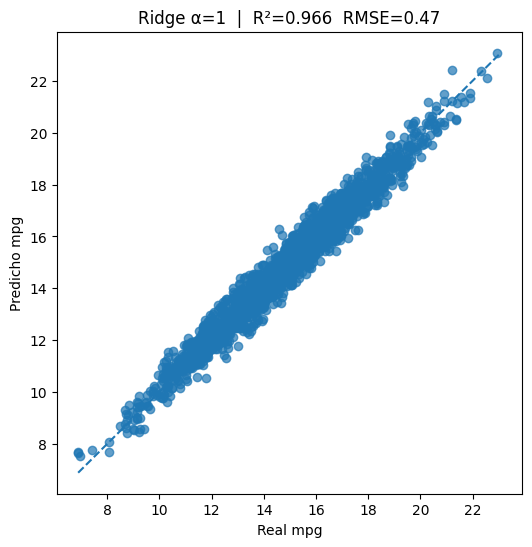

In [21]:
#@title Gráfica real vs predicho (TEST)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')
plt.xlabel('Real mpg')
plt.ylabel('Predicho mpg')
plt.title(f'Ridge α={best_alpha}  |  R²={r2_test:.3f}  RMSE={rmse_test:.2f}')
plt.show()


In [22]:
#@title Coeficientes (estandarizados)
ridge_step = best_model.named_steps['ridge']
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef_estandarizado': ridge_step.coef_
}).sort_values('coef_estandarizado', key=np.abs, ascending=False).reset_index(drop=True)
coef_df


,feature,coef_estandarizado
0,vehicle_weight,-2.502212
1,horsepower,0.293446
2,engine_displacement,0.009450
3,model_year,0.003921


In [24]:
#@title Resumen tipo test
answers = {}
missing_series = df.isna().sum()
answers['P1_missing_column'] = missing_series[missing_series>0].index.tolist()
answers['P2_median_hp'] = float(df['horsepower'].median())
answers['P3_imputation'] = 'media/mediana (no 0)'
answers['P4_best_alpha'] = best_alpha
answers['P5_rmse_std_cv'] = float(std_rmse_cv)
answers['P6_r2_test'] = float(r2_test)
answers


{'P1_missing_column': ['horsepower'],
 'P2_median_hp': 149.0,
 'P3_imputation': 'media/mediana (no 0)',
 'P4_best_alpha': 1,
 'P5_rmse_std_cv': 0.009931365849625244,
 'P6_r2_test': 0.9656258293740484}